# ECON 422: Machine Learning Basics

This notebook accompanies the introductory framework for machine learning in economic analysis.

We will first distinguish among **supervised learning**, **unsupervised learning**, and **reinforcement learning**, and then focus on supervised learning, which is the type most commonly used in empirical economics.

The focus is the concept, not advanced machine-learning methods. We will use a **cross-sectional dataset** and OLS/linear regression as the main example.

The basic supervised-learning setup is

$$
y = g(X),
$$

where the ideal relationship $g(\cdot)$ is unknown. We observe examples $(X_i,y_i)$ and use the data to learn an approximation

$$
\hat y = h(X;\phi).
$$

For OLS, the learned approximation is linear:

$$
\hat y = \hat\beta_0 + X^{\prime}\hat\beta.
$$

The main ideas we will practice are:

- **features** $X$;
- **target** $y$;
- **training data**;
- **test data**;
- **prediction**;
- **loss**; and
- **out-of-sample evaluation**.


## Three broad types of machine learning

Machine-learning methods are commonly grouped into three broad categories.

| Type | What is observed? | Main goal | Economic examples |
|---|---|---|---|
| **Supervised learning** | Features $X$ and an observed target $y$ | Learn a relationship between $X$ and $y$ | Forecast GDP growth or inflation; predict house prices; classify default risk |
| **Unsupervised learning** | Features $X$, but no target $y$ | Discover patterns or structure in the data | Cluster countries or firms; use PCA/factor methods to summarize macro data; extract topics from text |
| **Reinforcement learning** | States, actions, and rewards over time | Learn a decision rule that maximizes cumulative rewards | Sequential pricing or inventory decisions; dynamic portfolio decisions; adaptive policy or treatment rules |

### Which type is most common in economics?

Empirical economics relies most heavily on **supervised learning**. Economists often study an observed outcome $y$ as a function of covariates $X$, whether the goal is:

- **forecasting** an economic outcome;
- estimating **heterogeneous effects**; or
- using machine learning to estimate **nuisance functions** inside a larger econometric procedure.

**Unsupervised learning** is also widely used for dimension reduction, factor extraction, clustering, and exploratory analysis. **Reinforcement learning** is less common in mainstream empirical economics, although it is closely related to dynamic decision problems.

A key distinction is that economics is often interested not only in **prediction**, but also in **estimation and inference**. Machine-learning methods may therefore be used as components of a broader econometric analysis rather than treating prediction itself as the final objective.

The rest of this notebook focuses on **supervised learning** and the basic prediction workflow.


## What is supervised learning?

In supervised learning, the data contain both:

- **features** $X$: variables used to make a prediction;
- **target** $y$: the observed outcome we want to predict.

The computer learns a rule from observed examples $(X_i,y_i)$.

Examples include:

| Problem | Features $X$ | Target $y$ |
|---|---|---|
| House-price prediction | size, age, location | sale price |
| Wage prediction | education, experience | wage |
| Inflation forecasting | macroeconomic indicators | future inflation |
| Recession classification | macro/financial indicators | recession = 0 or 1 |

Regression and classification are two common supervised-learning problems.

In this notebook, we use a **cross-sectional house-price regression example**.


## Why is OLS supervised learning?

OLS is a supervised-learning method because it learns a relationship between observed features and an observed target.

For a linear model,

$$
\hat y_i = \hat\beta_0 + X_i^{\prime}\hat\beta.
$$

OLS chooses the coefficients to minimize squared error:

$$
\sum_{i=1}^n (y_i-\hat y_i)^2.
$$

So OLS already contains the main ingredients of supervised learning:

1. observed features $X$;
2. an observed target $y$;
3. a model;
4. model parameters to learn;
5. a loss function;
6. training; and
7. prediction.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(422)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## A simple cross-sectional dataset

Suppose we observe data on individual houses.

For each house, we observe:

- `size`: square footage;
- `bedrooms`: number of bedrooms;
- `age`: age of the house in years;
- `distance`: distance from downtown in miles;
- `price`: sale price, measured in thousands of dollars.

Each row is a different house. There is **no time ordering** in this example.

In [2]:
n = 300

size = np.random.normal(1800, 450, n)
size = np.clip(size, 700, 3500)

bedrooms = np.random.choice([2, 3, 4, 5], size=n, p=[0.15, 0.45, 0.30, 0.10])
age = np.random.uniform(0, 60, n)
distance = np.random.uniform(1, 25, n)

price = (
    80
    + 0.18 * size
    + 18 * bedrooms
    - 1.2 * age
    - 4.0 * distance
    + np.random.normal(0, 35, n)
)

df = pd.DataFrame({
    "size": size,
    "bedrooms": bedrooms,
    "age": age,
    "distance": distance,
    "price": price
})

df.head()

,size,bedrooms,age,distance,price
0,"1,489.669",4,10.387,2.422,352.955
1,"1,199.674",4,8.473,15.753,250.750
2,"2,049.531",3,38.451,4.726,511.334
3,"1,451.482",3,22.865,3.605,327.217
4,"1,829.457",3,45.804,1.074,337.503


### Features and target

We will use

$$
X = \{\text{size, bedrooms, age, distance}\}
$$

to predict

$$
y = \text{price}.
$$

In machine-learning language:

- the columns of $X$ are the **features**;
- $y$ is the **target**.

In [3]:
features = ["size", "bedrooms", "age", "distance"]

X = df[features]
y = df["price"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

display(X.head())

Shape of X: (300, 4)
Shape of y: (300,)


,size,bedrooms,age,distance
0,"1,489.669",4,10.387,2.422
1,"1,199.674",4,8.473,15.753
2,"2,049.531",3,38.451,4.726
3,"1,451.482",3,22.865,3.605
4,"1,829.457",3,45.804,1.074


## Training sample and test sample

A central idea in supervised learning is that we should not judge a model only by how well it fits the observations used to estimate it. A sufficiently flexible model may fit the training data very well but perform poorly on new observations. This is **overfitting**.

We therefore split the sample into:

- **training sample**: used to learn the model;
- **test sample**: reserved for evaluating the learned model on observations that were not used in training.

Because the housing data are cross-sectional and have no meaningful time ordering, we can randomly assign observations to the training and test samples. Here we use 75\% for training and 25\% for testing.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=422
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 225
Test observations: 75


## Train the OLS model

Training means using the training data to learn the model parameters.

For OLS, the learned parameters are the estimated coefficients:

$$
\hat\beta_0,\hat\beta_1,\ldots,\hat\beta_p.
$$

In [5]:
ols = LinearRegression()

# Training
ols.fit(X_train, y_train)

print("Intercept:", round(ols.intercept_, 3))

coef_table = pd.DataFrame({
    "Feature": features,
    "Estimated coefficient": ols.coef_
})

display(coef_table)

Intercept: 96.668


,Feature,Estimated coefficient
0,size,0.178
1,bedrooms,15.021
2,age,-1.142
3,distance,-4.254


## Make predictions

After training, the model can take the features of a house and generate a predicted price.

For each observation in the test sample,

$$
\hat y_i = h(X_i,\hat\phi).
$$

For OLS, $\hat\phi$ is the set of estimated regression coefficients.

In [6]:
y_pred = ols.predict(X_test)

prediction_table = pd.DataFrame({
    "Actual price": y_test.values,
    "Predicted price": y_pred
})

prediction_table.head(10)

,Actual price,Predicted price
0,488.633,484.365
1,331.722,332.277
2,385.448,359.020
3,447.893,451.283
4,339.542,370.994
5,286.962,274.463
6,492.286,525.366
7,256.851,278.668
8,266.947,237.754
9,513.437,509.916


## Loss and model evaluation

A **loss function** measures how far predictions are from the observed targets.

For example, squared error for observation $i$ is

$$
(y_i-\hat y_i)^2.
$$

A common summary is mean squared error:

$$
MSE
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2.
$$

We will also calculate:

$$
RMSE = \sqrt{MSE},
$$

and

$$
MAE
=
\frac{1}{n}
\sum_{i=1}^{n}|y_i-\hat y_i|.
$$

Another commonly used measure is

$$
R^2
=
1-
\frac{\sum_i (y_i-\hat y_i)^2}
{\sum_i (y_i-\bar y)^2}.
$$

For RMSE and MAE, **smaller is better**. For $R^2$, **larger is better**.


In [7]:
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("Test MSE :", round(test_mse, 3))
print("Test RMSE:", round(test_rmse, 3))
print("Test MAE :", round(test_mae, 3))
print("Test R^2 :", round(test_r2, 3))

Test MSE : 726.384
Test RMSE: 26.952
Test MAE : 21.493
Test R^2 : 0.929


## Training performance versus test performance

The model was estimated using the training sample, so it is useful to compare:

- performance on the **training sample**;
- performance on the **test sample**.

The test sample gives us a first idea of how well the learned rule works on new observations.

Comparing training and test performance can also help us recognize **overfitting**. A model may fit the training observations very well but perform substantially worse on observations that were not used during training.


In [8]:
train_pred = ols.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Training RMSE:", round(train_rmse, 3))
print("Test RMSE    :", round(test_rmse, 3))

Training RMSE: 35.126
Test RMSE    : 26.952


## Visualizing actual and predicted values

If the model predicted perfectly, every point would lie on the 45-degree line.

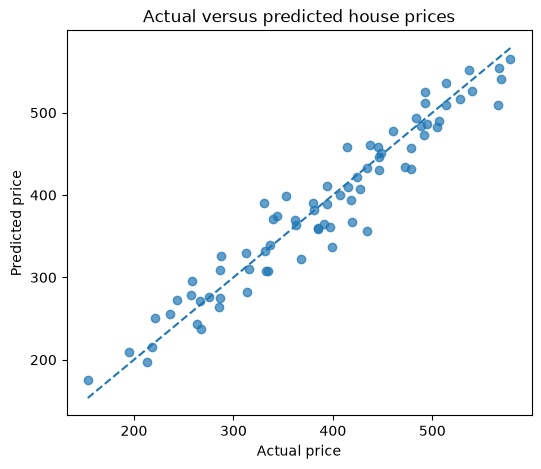

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_pred, alpha=0.7)

lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

ax.plot([lower, upper], [lower, upper], linestyle="--")

ax.set_xlabel("Actual price")
ax.set_ylabel("Predicted price")
ax.set_title("Actual versus predicted house prices")

plt.show()

## Prediction for a new observation

Suppose we observe a new house with:

- size = 2,000 square feet;
- bedrooms = 3;
- age = 10 years;
- distance = 5 miles from downtown.

The trained model can use these features to predict the sale price.

In [10]:
new_house = pd.DataFrame({
    "size": [2000],
    "bedrooms": [3],
    "age": [10],
    "distance": [5]
})

new_house_prediction = ols.predict(new_house)[0]

print("Predicted price (thousand dollars):", round(new_house_prediction, 3))

Predicted price (thousand dollars): 464.306


## The supervised-learning workflow

For the cross-sectional example in this notebook, the main workflow is:

$$
\boxed{
(X,y)
\longrightarrow
\text{split the sample}
\longrightarrow
\text{train on the training sample}
\longrightarrow
\text{predict in the test sample}
\longrightarrow
\text{evaluate test loss}
}
$$

For our housing application:

$$
\boxed{
\text{house characteristics}
\longrightarrow
\text{OLS training}
\longrightarrow
\text{predicted house price}
}
$$

The important idea is broader than OLS: **many machine-learning methods use the same supervised-learning framework but choose a different model class or training rule.**


# Teaser: Other Supervised-Learning Methods

You do **not** need to learn these methods yet.

Later in the course, we will study methods that use the same supervised-learning framework but learn the prediction rule in different ways.

Examples include:

- **Ridge regression**: linear regression with coefficient shrinkage;
- **Lasso**: linear regression with shrinkage and variable selection;
- **Decision trees**: prediction through a sequence of data-based splitting rules;
- **Random forests**: average predictions from many trees;
- **Gradient boosting**: combine many small prediction models sequentially;
- **Neural networks**: use layers of nonlinear transformations to learn complex relationships.

The key point for now is:

$$
\boxed{
\text{Different methods, same supervised-learning idea: learn from labeled examples.}
}
$$